In [1]:
!pip install astropy

### des_dr2 y6_gold

In [2]:
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import linregress

Una vez descargados los datos de y6_gold desde DES Data Release File Server y los datos de DES desde GitHub, se ha realizado un crossmatch de cada uno de los archivos parquet de Y6 Gold con DES. Como los crossmatches se han realizado por separado, se han unido en un único archivo en otro notebook. Ahora estudiaremos los ángulos de posición.

In [3]:
#Ruta al archivo
crossmatch_file = '/mnt/c/Users/Leire/Downloads/crossmatches/Y6_GOLD_2_2_FULL_crossmatch.csv'

In [4]:
#Cargamos el catálogo
y6_gold_crossmatch = pd.read_csv(crossmatch_file)

In [5]:
print(y6_gold_crossmatch.shape)

(744, 95)


In [6]:
print(y6_gold_crossmatch.columns)

Index(['Index_1', 'J2000_NAME', 'OCARS_NAME', 'DEC', 'RA', 'DEC_deg', 'RA_deg',
       'INDEX_NEW_TABLE', 'RA_ERR_sec', 'DEC_ERR_arcsec', 'RA_ERR_deg',
       'DEC_ERR_deg', 'SKY_PA_ERR_deg', 'RA_DEC_CORRELATION',
       'SEMIMAJOR_AXIS_OF_ERROR_ELLIPSE_mas', 'CATALOG_CODE', 'EPOCH_YEAR',
       'GAL_LON_deg', 'GAL_LAT_deg', 'Z_FROM_NED_OR_LITERATURE', 'Z', 'Z_FLAG',
       'Z_SIMBAD', 'Z_SIMBAD_FLAG', 'Z_SDSS', 'OPTICAL_OR_NIR_MAGNITUDE',
       'BAND', 'OBJECT_PRIMARY_TYPE', 'OTHER_ID_AND_NOTES', 'J2000',
       'frequencies', 'pa', 'pa_err', 'flag180', 'separation_1', 'sys_err_1',
       'tot_err_1', 'Index_2', 'Astrogeo_DES_full_catalogue_matches_good_RA',
       'Astrogeo_DES_full_catalogue_matches_good_DEC',
       'DES_full_catalogue_Astrogeo_matches_RA',
       'DES_full_catalogue_Astrogeo_matches_DEC',
       'DES_full_catalogue_Astrogeo_matches_indexes',
       'DES_full_catalogue_Astrogeo_matches_indexes_of_DES_full_catalogue',
       'DES_full_catalogue_Astrogeo_A_matches',

Una vez más, vamos a filtrar el catálogo por tipo galaxia.

In [7]:
#Filtramos por los que sean galaxias
y6_gold_crossmatch_good = y6_gold_crossmatch[(y6_gold_crossmatch['DES_full_catalogue_Astrogeo_EXTENDED_CLASS_COADD_matches'].isin([2, 3]))]

In [8]:
print(y6_gold_crossmatch_good.shape)

(263, 95)


#### a DES vs Y6 GOLD

Regresión lineal: y = 1.0000*x + -0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


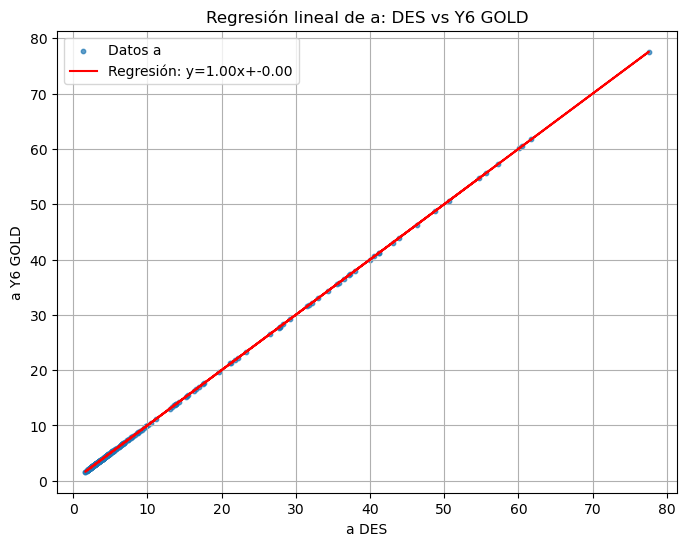

In [9]:
#Extraemos las columnas a de ambos surveys de los datos crossmatched
x = y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_A_matches']
y = y6_gold_crossmatch_good['A_IMAGE']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a DES')
plt.ylabel('a Y6 GOLD')
plt.title('Regresión lineal de a: DES vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

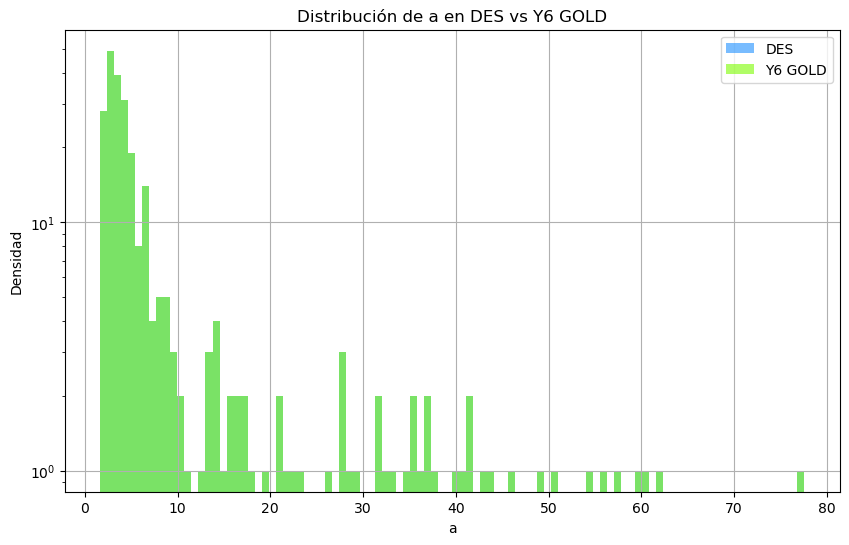

In [10]:
#Histograma de los a
plt.figure(figsize=(10, 6))
plt.hist(y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_A_matches'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(y6_gold_crossmatch_good['A_IMAGE'], bins=100, color='lawngreen', alpha=0.6, label='Y6 GOLD')
plt.yscale('log')
plt.xlabel('a')
plt.ylabel('Densidad')
plt.title('Distribución de a en DES vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

#### b DES vs Y6 GOLD

Regresión lineal: y = 1.0000*x + -0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


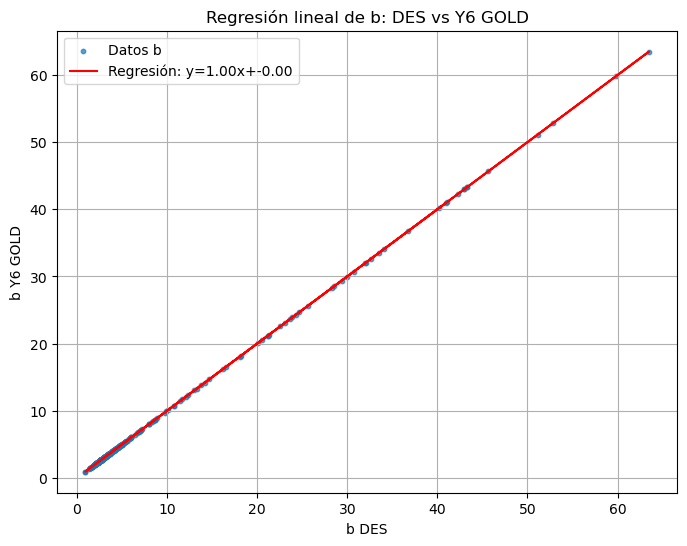

In [11]:
#Extraemos las columnas b de ambos surveys de los datos crossmatched
x = y6_gold_crossmatch['DES_full_catalogue_Astrogeo_B_matches']
y = y6_gold_crossmatch['B_IMAGE']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b DES')
plt.ylabel('b Y6 GOLD')
plt.title('Regresión lineal de b: DES vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

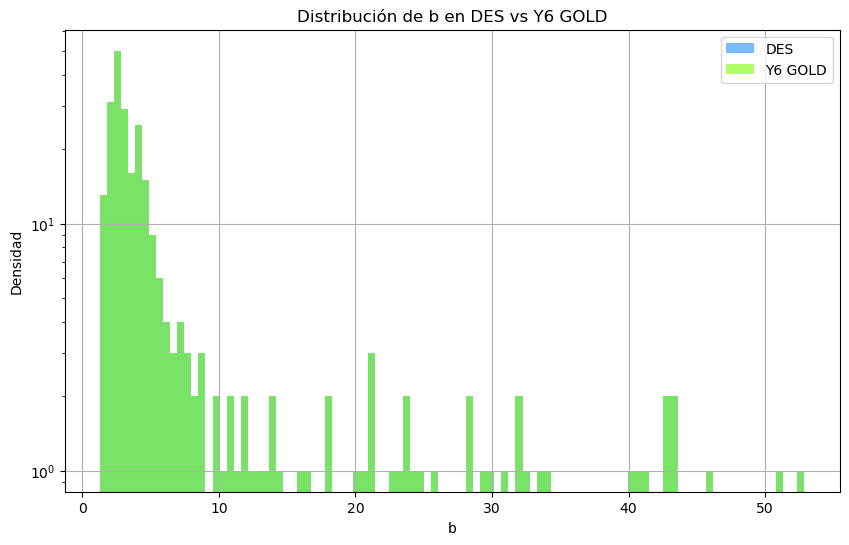

In [12]:
#Histograma de los b
plt.figure(figsize=(10, 6))
plt.hist(y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_B_matches'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(y6_gold_crossmatch_good['B_IMAGE'], bins=100, color='lawngreen', alpha=0.6, label='Y6 GOLD')
plt.yscale('log')
plt.xlabel('b')
plt.ylabel('Densidad')
plt.title('Distribución de b en DES vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

#### PA DES vs Y6 GOLD

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


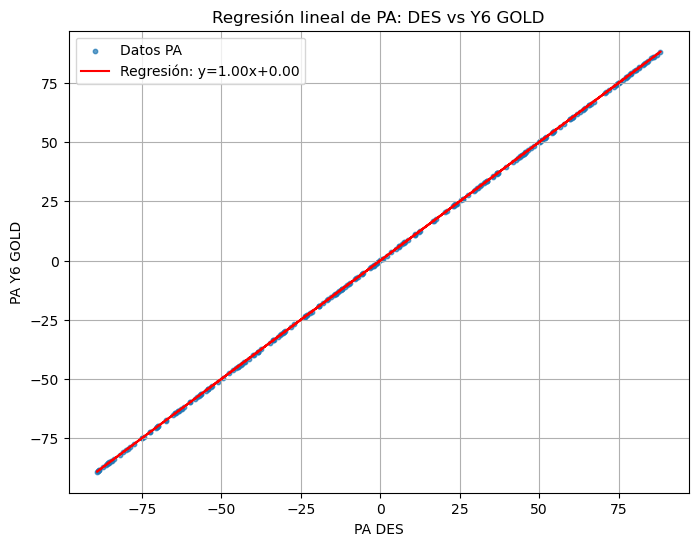

In [13]:
#Extraemos las columnas PA de ambos surveys de los datos crossmatched
x = y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_THETA_J2000_matches']
y = y6_gold_crossmatch_good['THETA_J2000']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA DES')
plt.ylabel('PA Y6 GOLD')
plt.title('Regresión lineal de PA: DES vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

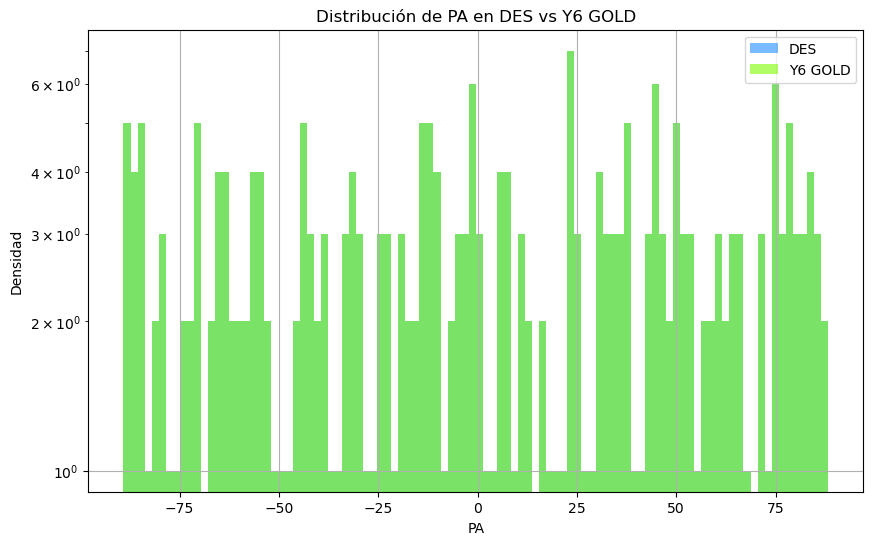

In [14]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_THETA_J2000_matches'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(y6_gold_crossmatch_good['THETA_J2000'], bins=100, color='lawngreen', alpha=0.6, label='Y6 GOLD')
plt.yscale('log')
plt.xlabel('PA')
plt.ylabel('Densidad')
plt.title('Distribución de PA en DES vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

#### Elipticidades DES vs Y6 GOLD

Primero, calculamos las elipticidades de DES para compararlas con las de Y6 GOLD.

In [15]:
#Extraemos columnas relevantes
a = y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_A_matches']  #eje mayor
b = y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_B_matches']  #eje menor
theta = np.deg2rad(y6_gold_crossmatch_good['DES_full_catalogue_Astrogeo_THETA_J2000_matches'])  #ángulo de posición

#Calculamos q y las elipticidades
q = b/a
e = (1 - q)/(1 + q)

e1 = e*np.cos(2*theta)
e2 = e*np.sin(2*theta)

#Añadimos nuevas columnas a la tabla
y6_gold_crossmatch_good.loc[:, 'e1_des'] = e1
y6_gold_crossmatch_good.loc[:, 'e2_des'] = e2

/tmp/ipykernel_26582/1347303714.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y6_gold_crossmatch_good.loc[:, 'e1_des'] = e1
/tmp/ipykernel_26582/1347303714.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y6_gold_crossmatch_good.loc[:, 'e2_des'] = e2


In [16]:
e1_min_des = y6_gold_crossmatch_good['e1_des'].min()
e1_max_des = y6_gold_crossmatch_good['e1_des'].max()
e1_min_y6_gold_bdf = y6_gold_crossmatch_good['BDF_G_1'].min()
e1_max_y6_gold_bdf = y6_gold_crossmatch_good['BDF_G_1'].max()
e1_min_y6_gold_psf = y6_gold_crossmatch_good['PSF_G_1'].min()
e1_max_y6_gold_psf = y6_gold_crossmatch_good['PSF_G_1'].max()

print(f"DES e1 entre {e1_min_des} y {e1_max_des}")
print(f"Y6 GOLD BDF e1 entre {e1_min_y6_gold_bdf} y {e1_max_y6_gold_bdf}")
print(f"Y6 GOLD PSF e1 entre {e1_min_y6_gold_psf} y {e1_max_y6_gold_psf}")

DES e1 entre -0.33975598349837177 y 0.2646084922868716
Y6 GOLD BDF e1 entre -9999000000.0 y 0.75754597227723
Y6 GOLD PSF e1 entre -9999000000.0 y 0.0385840158584431


In [17]:
e2_min_des = y6_gold_crossmatch_good['e2_des'].min()
e2_max_des = y6_gold_crossmatch_good['e2_des'].max()
e2_min_y6_gold_bdf = y6_gold_crossmatch_good['BDF_G_2'].min()
e2_max_y6_gold_bdf = y6_gold_crossmatch_good['BDF_G_2'].max()
e2_min_y6_gold_psf = y6_gold_crossmatch_good['PSF_G_2'].min()
e2_max_y6_gold_psf = y6_gold_crossmatch_good['PSF_G_2'].max()

print(f"DES e2 entre {e2_min_des} y {e2_max_des}")
print(f"Y6 GOLD BDF e2 entre {e2_min_y6_gold_bdf} y {e2_max_y6_gold_bdf}")
print(f"Y6 GOLD PSF e2 entre {e2_min_y6_gold_psf} y {e2_max_y6_gold_psf}")

DES e2 entre -0.30476706024247113 y 0.3788060779045572
Y6 GOLD BDF e2 entre -9999000000.0 y 0.364485805020601
Y6 GOLD PSF e2 entre -9999000000.0 y 0.0255371192910383


Vamos a quitar los e1 y e2 que nos van a dar problemas.

In [18]:
#Con esto quitamos los objetos que tengan valores de -9999.0 en cualquiera de estas columnas
columnas_malas_y6 = ['BDF_G_1', 'BDF_G_2', 'PSF_G_1', 'PSF_G_2']

mask_y6 = ~(y6_gold_crossmatch_good[columnas_malas_y6] < -9999.0).any(axis=1)

crossmatch_des_y6_gold_good = y6_gold_crossmatch_good[mask_y6].copy()

print('Objetos totales antes:', len(y6_gold_crossmatch))
print('Galaxias antes:', len(y6_gold_crossmatch_good))
print('Objetos eliminados:', (~mask_y6).sum())
print('Galaxias restantes:', len(crossmatch_des_y6_gold_good))

Objetos totales antes: 744
Galaxias antes: 263
Objetos eliminados: 2
Galaxias restantes: 261


Regresión lineal: y = -0.9394*x + 0.0025
Coeficiente de correlación (r): -0.6776
Error estándar: 0.0633
p-valor: 1.9495e-36


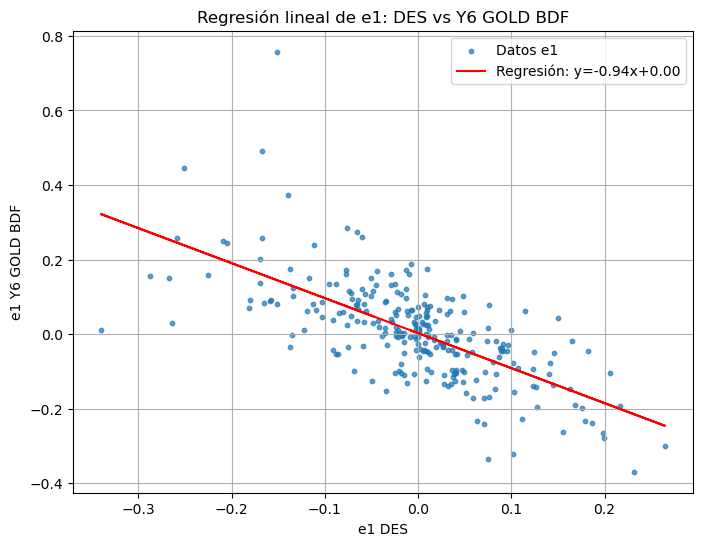

In [19]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_des_y6_gold_good['e1_des']
y = crossmatch_des_y6_gold_good['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 DES')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: DES vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.0000*x + 0.0064
Coeficiente de correlación (r): -0.0002
Error estándar: 0.0075
p-valor: 9.9780e-01


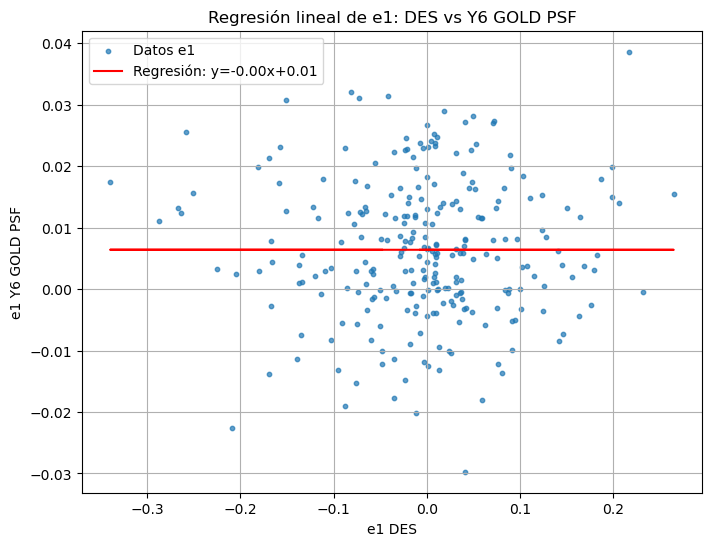

In [20]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_des_y6_gold_good['e1_des']
y = crossmatch_des_y6_gold_good['PSF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 DES')
plt.ylabel('e1 Y6 GOLD PSF')
plt.title('Regresión lineal de e1: DES vs Y6 GOLD PSF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.9375*x + -0.0065
Coeficiente de correlación (r): -0.6554
Error estándar: 0.0671
p-valor: 2.0502e-33


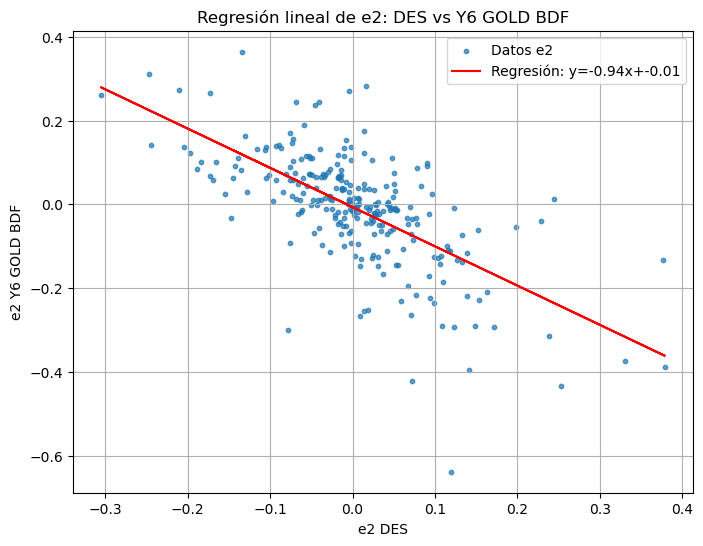

In [21]:
#Extraemos las columnas e2 de ambos surveys de los datos crossmatched
x = crossmatch_des_y6_gold_good['e2_des']
y = crossmatch_des_y6_gold_good['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 DES')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: DES vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.0086*x + 0.0014
Coeficiente de correlación (r): 0.0910
Error estándar: 0.0059
p-valor: 1.4259e-01


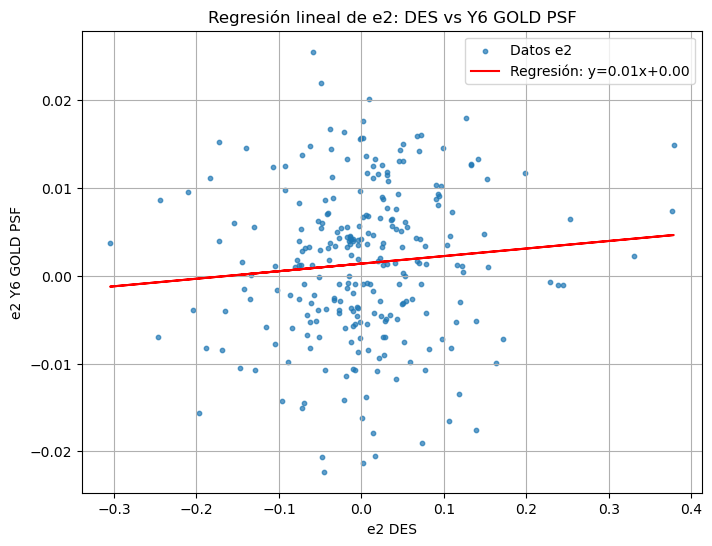

In [22]:
#Extraemos las columnas e2 de ambos surveys de los datos crossmatched
x = crossmatch_des_y6_gold_good['e2_des']
y = crossmatch_des_y6_gold_good['PSF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 DES')
plt.ylabel('e2 Y6 GOLD PSF')
plt.title('Regresión lineal de e2: DES vs Y6 GOLD PSF')
plt.legend()
plt.grid(True)
plt.show()

Vamos a calcular el PA y los ejes a partir de las elipticidades, y compararlos con los que ya teníamos.

#### Cálculo PA y ejes

In [23]:
#Definimos una función que nos calcule el PA, los ejes y el módulo de la elipticidad
def calcular_pa_ejes(df, e1_col, e2_col, T_col, prefix):
    
    e1 = df[e1_col].astype(float).to_numpy()
    e2 = df[e2_col].astype(float).to_numpy()
    T  = df[T_col].astype(float).to_numpy()
    
    #modulo de la elipticidad
    eps = np.sqrt(e1**2 + e2**2)
    
    #axis ratio b/a
    q = (1 - eps) / (1 + eps)
    
    #PA
    phi_rad = 0.5*np.arctan2(e2, e1)
    phi = np.degrees(phi_rad) % 180 #para que esté en el rango [0, 180]

    #cálculo de a y b
    arg = T/(1 + q**2) #evitamos que la raíz sea negativa
    a = np.sqrt(np.maximum(arg, 0))
    b = a*q

    #añadimos dependiendo de qué variables se han utilizado
    df[f'{prefix}_a'] = a
    df[f'{prefix}_b'] = b
    df[f'{prefix}_phi'] = phi
    
    return df

In [24]:
crossmatch_y6 = crossmatch_des_y6_gold_good.copy()

#BDF
crossmatch_y6 = calcular_pa_ejes(crossmatch_y6, 'BDF_G_1', 'BDF_G_2', 'BDF_T', prefix='BDF')

#PSF
crossmatch_y6 = calcular_pa_ejes(crossmatch_y6, 'PSF_G_1', 'PSF_G_2', 'PSF_T', prefix='PSF')

Regresión lineal: y = 0.5881*x + 89.7650
Coeficiente de correlación (r): 0.5739
Error estándar: 0.0521
p-valor: 2.8836e-24


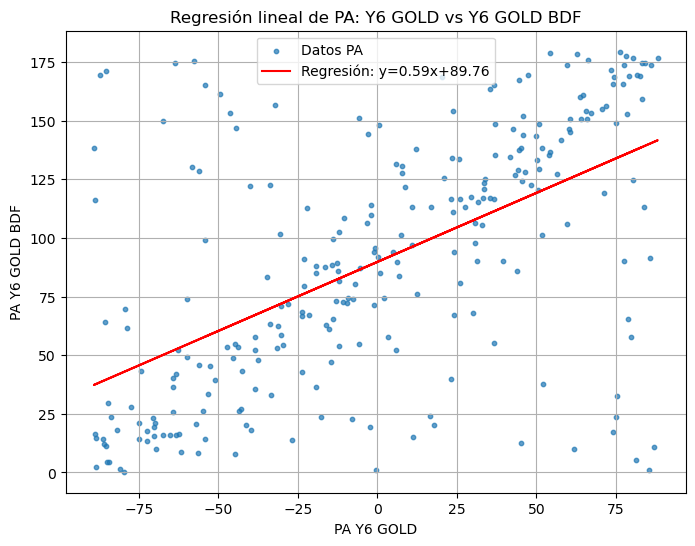

In [25]:
#Extraemos las columnas PA 
x = crossmatch_y6['THETA_J2000']
y = crossmatch_y6['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA Y6 GOLD')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: Y6 GOLD vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.0751*x + 83.7659
Coeficiente de correlación (r): -0.0620
Error estándar: 0.0750
p-valor: 3.1823e-01


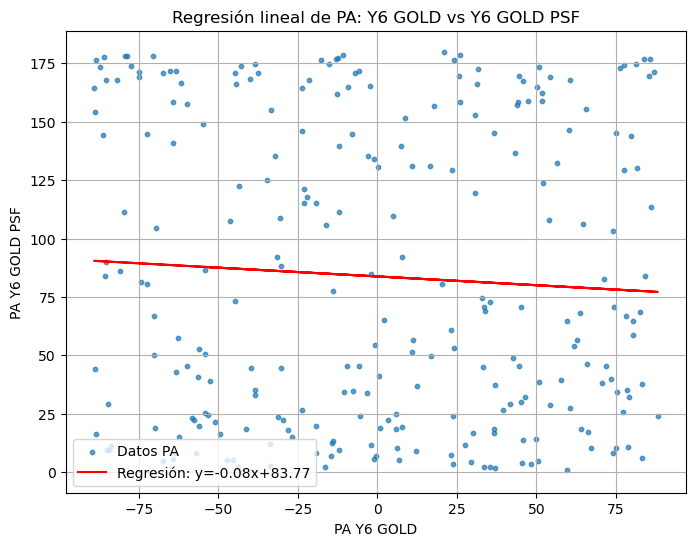

In [26]:
#Extraemos las columnas PA 
x = crossmatch_y6['THETA_J2000']
y = crossmatch_y6['PSF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA Y6 GOLD')
plt.ylabel('PA Y6 GOLD PSF')
plt.title('Regresión lineal de PA: Y6 GOLD vs Y6 GOLD PSF')
plt.legend()
plt.grid(True)
plt.show()

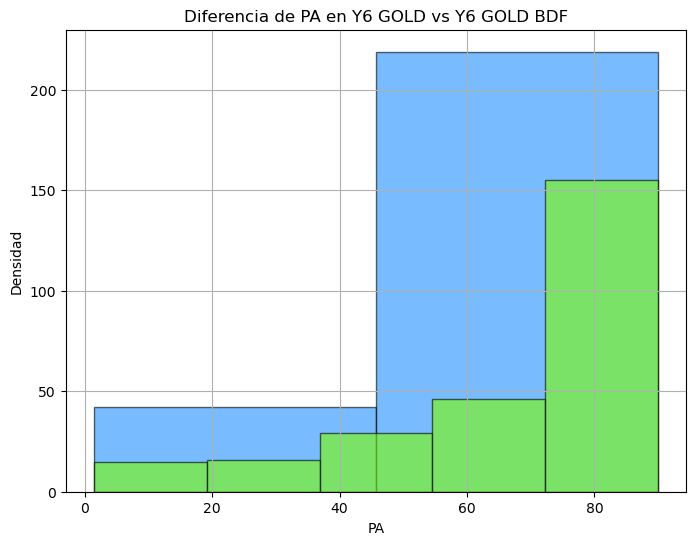

In [27]:
#Hacemos un histograma de la resta entre PA_BDF y PA_Y6
crossmatch_y6['delta_PA'] = (crossmatch_y6['BDF_phi'] - crossmatch_y6['THETA_J2000']) % 180
crossmatch_y6['delta_PA'] = np.where(crossmatch_y6['delta_PA'] > 90, 180 - crossmatch_y6['delta_PA'], crossmatch_y6['delta_PA'])

plt.figure(figsize=(8, 6))
plt.hist(crossmatch_y6['delta_PA'], bins=2, color='dodgerblue', alpha=0.6, edgecolor='black')
plt.hist(crossmatch_y6['delta_PA'], bins=5, color='lawngreen', alpha=0.6, edgecolor='black')
plt.xlabel('PA')
plt.ylabel('Densidad')
plt.title('Diferencia de PA en Y6 GOLD vs Y6 GOLD BDF')
plt.grid(True)
plt.show()

Regresión lineal: y = 0.2982*x + -0.6662
Coeficiente de correlación (r): 0.8431
Error estándar: 0.0118
p-valor: 1.0118e-71


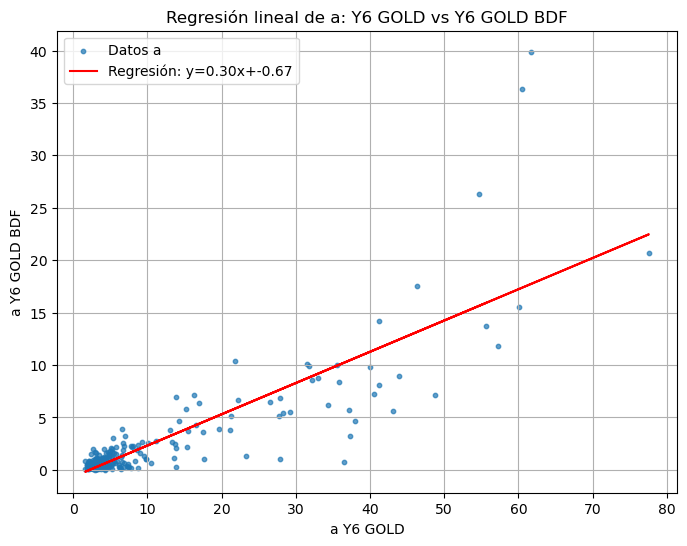

In [28]:
#Extraemos las columnas a 
x = crossmatch_y6['A_IMAGE']
y = crossmatch_y6['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a Y6 GOLD')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: Y6 GOLD vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Vamos a hacer un zoom y luego hacer la regresión lineal para ver si queda mejor.

Regresión lineal: y = 0.1919*x + -0.0331
Coeficiente de correlación (r): 0.8158
Error estándar: 0.0087
p-valor: 1.7294e-59


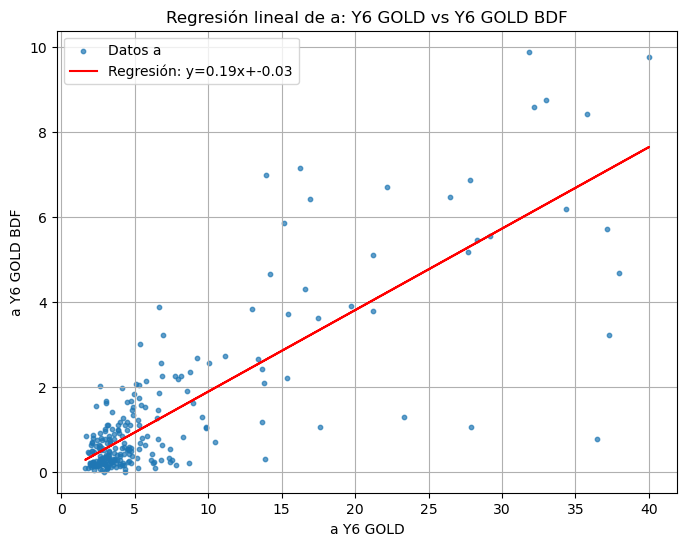

In [29]:
#Extraemos las columnas a 
x = crossmatch_y6['A_IMAGE']
y = crossmatch_y6['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos un recorte: x en [0,40] y y en [0,10]
zoom_mask = (x_clean >= 0) & (x_clean <= 40) & (y_clean >= 0) & (y_clean <= 10)
x_zoom = x_clean[zoom_mask]
y_zoom = y_clean[zoom_mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_zoom, y_zoom)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_zoom, y_zoom, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_zoom, slope*x_zoom + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a Y6 GOLD')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: Y6 GOLD vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.1835*x + -0.0446
Coeficiente de correlación (r): 0.6742
Error estándar: 0.0136
p-valor: 1.6077e-30


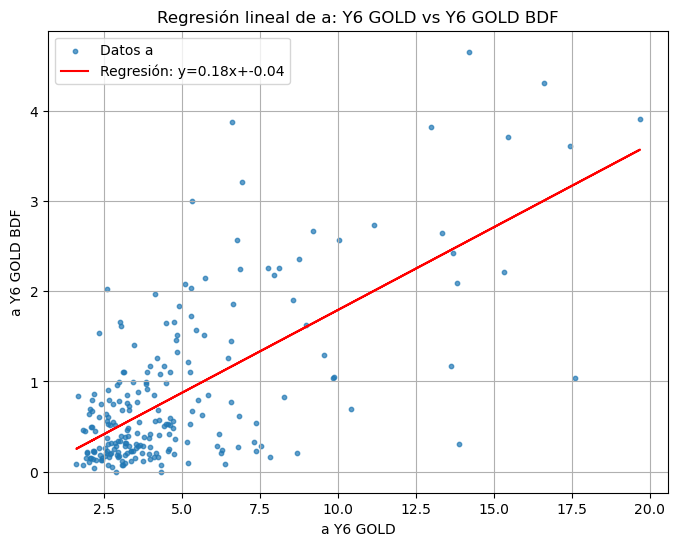

In [30]:
#Extraemos las columnas a 
x = crossmatch_y6['A_IMAGE']
y = crossmatch_y6['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos un recorte: x en [0,20] y y en [0,5]
zoom_mask = (x_clean >= 0) & (x_clean <= 20) & (y_clean >= 0) & (y_clean <= 5)
x_zoom = x_clean[zoom_mask]
y_zoom = y_clean[zoom_mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_zoom, y_zoom)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_zoom, y_zoom, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_zoom, slope*x_zoom + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a Y6 GOLD')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: Y6 GOLD vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.0002*x + 0.7383
Coeficiente de correlación (r): -0.0693
Error estándar: 0.0002
p-valor: 2.6472e-01


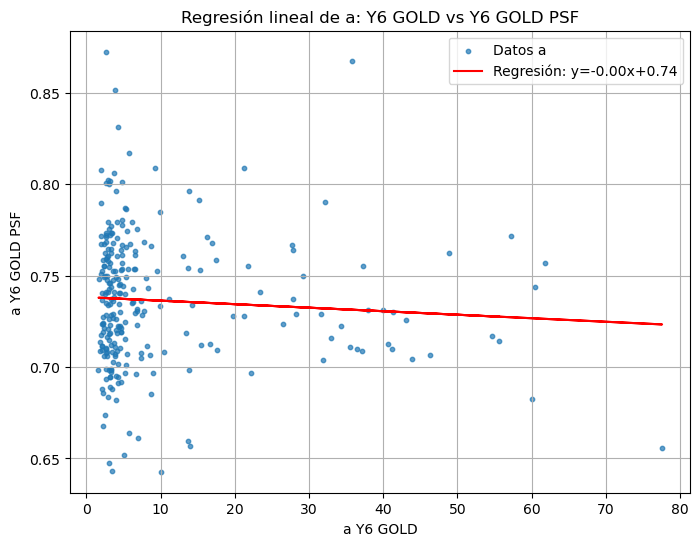

In [31]:
#Extraemos las columnas a 
x = crossmatch_y6['A_IMAGE']
y = crossmatch_y6['PSF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a Y6 GOLD')
plt.ylabel('a Y6 GOLD PSF')
plt.title('Regresión lineal de a: Y6 GOLD vs Y6 GOLD PSF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.3307*x + -0.7382
Coeficiente de correlación (r): 0.8493
Error estándar: 0.0128
p-valor: 7.8892e-74


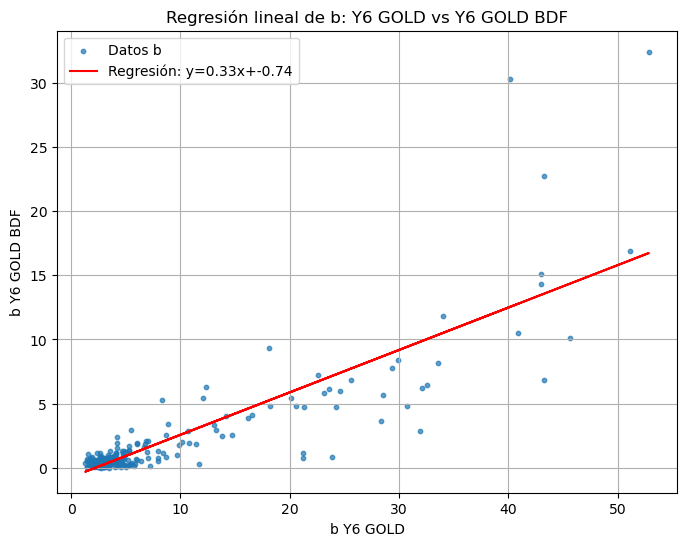

In [32]:
#Extraemos las columnas B 
x = crossmatch_y6['B_IMAGE']
y = crossmatch_y6['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b Y6 GOLD')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: Y6 GOLD vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Hacemos un zoom y luego hacemos la regresión lineal para ver si queda mejor.

Regresión lineal: y = 0.2229*x + -0.2434
Coeficiente de correlación (r): 0.7996
Error estándar: 0.0112
p-valor: 1.6487e-51


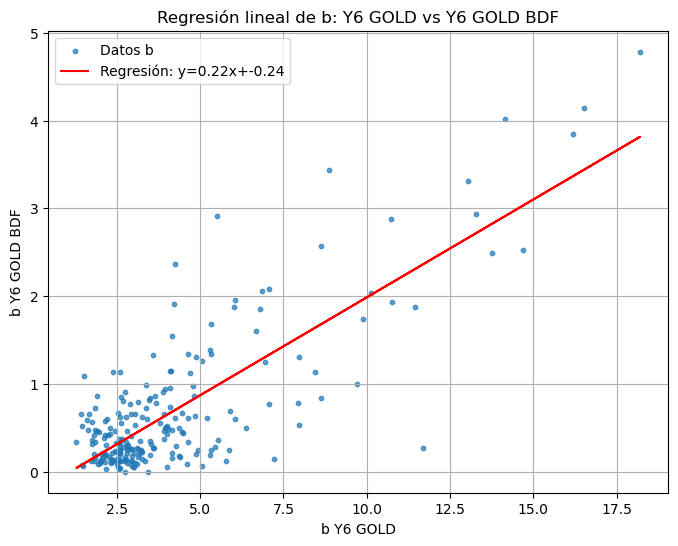

In [33]:
#Extraemos las columnas B 
x = crossmatch_y6['B_IMAGE']
y = crossmatch_y6['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos un recorte: x en [0,20] y y en [0,5]
zoom_mask = (x_clean >= 0) & (x_clean <= 20) & (y_clean >= 0) & (y_clean <= 5)
x_zoom = x_clean[zoom_mask]
y_zoom = y_clean[zoom_mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_zoom, y_zoom)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_zoom, y_zoom, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_zoom, slope*x_zoom + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b Y6 GOLD')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: Y6 GOLD vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.0001*x + 0.7172
Coeficiente de correlación (r): -0.0313
Error estándar: 0.0002
p-valor: 6.1490e-01


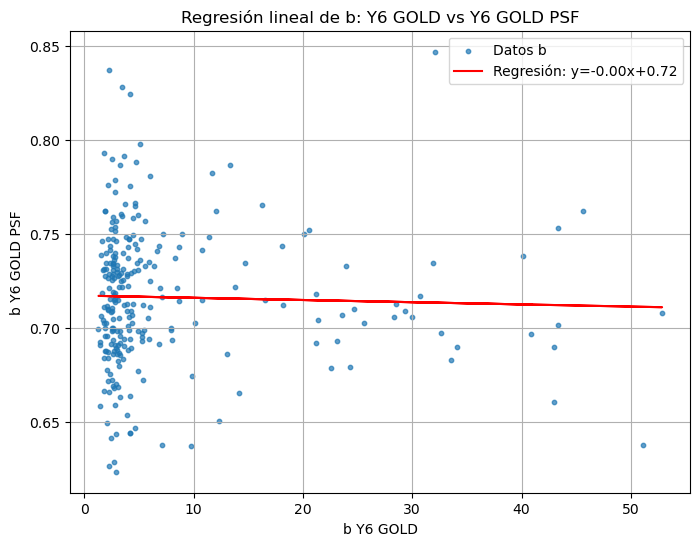

In [34]:
#Extraemos las columnas b 
x = crossmatch_y6['B_IMAGE']
y = crossmatch_y6['PSF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b Y6 GOLD')
plt.ylabel('b Y6 GOLD PSF')
plt.title('Regresión lineal de b: Y6 GOLD vs Y6 GOLD PSF')
plt.legend()
plt.grid(True)
plt.show()

#### DESI vs Y6 GOLD

In [35]:
#Ruta completa al archivo
desi_file = '/mnt/c/Users/Leire/Downloads/xmatch_astrogeo_desi.csv'

In [36]:
#Cargamos el catálogo
desi = pd.read_csv(desi_file)

In [37]:
#Creamos objetos en SkyCoord

#DESI
coords_desi = SkyCoord(ra=desi['RA_1'].values*u.degree, dec=desi['DEC_1'].values*u.degree)

#Y6 GOLD
coords_y6_gold = SkyCoord(ra=y6_gold_crossmatch['Astrogeo_DES_full_catalogue_matches_good_RA'].values*u.degree,
                      dec=y6_gold_crossmatch['Astrogeo_DES_full_catalogue_matches_good_DEC'].values*u.degree)

In [38]:
#Hacemos el crossmatch con un radio máximo
idx, d2d, _ = coords_y6_gold.match_to_catalog_sky(coords_desi)
max_sep = 1.0*u.arcsec
mask = d2d < max_sep

#Extraemos los datos que coinciden
y6_gold_matched = y6_gold_crossmatch[mask].reset_index(drop=True)
desi_matched = desi.iloc[idx[mask]].reset_index(drop=True)

#Combinamos los resultados en un solo DataFrame
crossmatched_y6_gold_desi = pd.concat([y6_gold_matched, desi_matched], axis=1)

#Guardamos el resultado en CSV
crossmatched_y6_gold_desi.to_csv('/mnt/c/Users/Leire/Downloads/Y6_GOLD_DESI_crossmatched.csv', index=False)
print(f"Crossmatch finalizado: {len(crossmatched_y6_gold_desi)} objetos encontrados.")

Crossmatch finalizado: 741 objetos encontrados.


In [39]:
#Extraemos columnas relevantes
a = crossmatched_y6_gold_desi['a_axis']  #eje mayor
b = crossmatched_y6_gold_desi['b_axis']  #eje menor
theta = np.deg2rad(crossmatched_y6_gold_desi['pos_angle'])  #ángulo de posición

#Calculamos q y las elipticidades
q = b/a
e = (1 - q)/(1 + q)

e1 = e*np.cos(2*theta)
e2 = e*np.sin(2*theta)

#Añadimos nuevas columnas a la tabla
crossmatched_y6_gold_desi['e1_desi'] = e1
crossmatched_y6_gold_desi['e2_desi'] = e2

In [40]:
#Con esto quitamos los objetos que tengan valores de -9999.0 en cualquiera de estas columnas
columnas_malas_y6 = ['BDF_G_1', 'BDF_G_2', 'PSF_G_1', 'PSF_G_2']

mask_y6_desi = ~(crossmatched_y6_gold_desi[columnas_malas_y6] < -9999.0).any(axis=1)

crossmatched_y6_gold_desi_clean = crossmatched_y6_gold_desi[mask_y6_desi].copy()

print('Objetos totales antes:', len(crossmatched_y6_gold_desi))
print('Objetos eliminados:', (~mask_y6_desi).sum())
print('Objetos restantes:', len(crossmatched_y6_gold_desi_clean))

Objetos totales antes: 741
Objetos eliminados: 2
Objetos restantes: 739


In [41]:
#Filtramos solo los tipos EXP, DEV y SER
tipos_filtrados = ['EXP', 'DEV', 'SER']
df_filtered = crossmatched_y6_gold_desi_clean[crossmatched_y6_gold_desi_clean['TYPE'].isin(tipos_filtrados)]

print('Objetos totales antes:', len(crossmatched_y6_gold_desi))
print('Objetos eliminados:', (~mask_y6_desi).sum())
print('Objetos restantes:', len(crossmatched_y6_gold_desi_clean))
print('Galaxias restantes:', len(df_filtered))

Objetos totales antes: 741
Objetos eliminados: 2
Objetos restantes: 739
Galaxias restantes: 145


Regresión lineal: y = -0.8705*x + 0.0019
Coeficiente de correlación (r): -0.9383
Error estándar: 0.0268
p-valor: 7.7519e-68


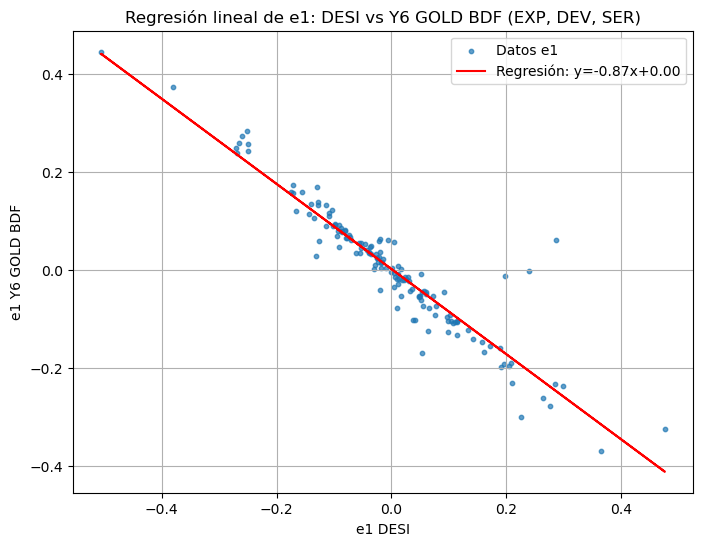

In [42]:
#Extraemos las columnas e1 de ambos surveys
x = df_filtered['e1_desi']
y = df_filtered['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 DESI')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: DESI vs Y6 GOLD BDF (EXP, DEV, SER)')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.8950*x + -0.0009
Coeficiente de correlación (r): -0.9551
Error estándar: 0.0232
p-valor: 2.0920e-77


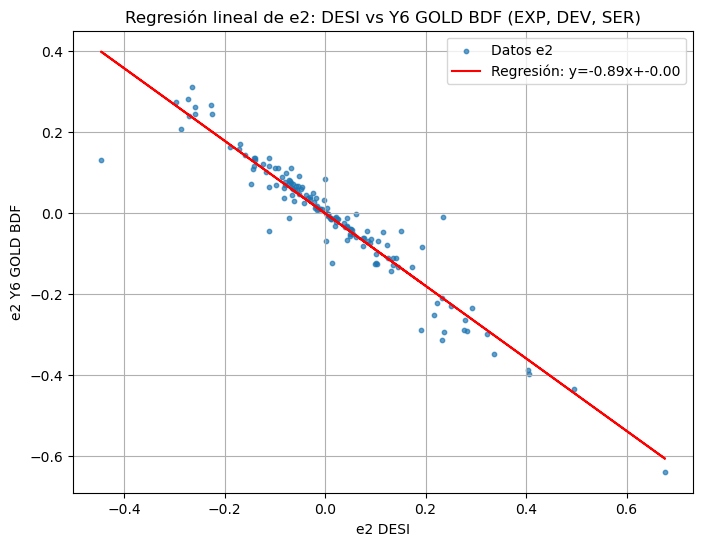

In [43]:
#Extraemos las columnas e1 de ambos surveys
x = df_filtered['e2_desi']
y = df_filtered['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 DESI')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: DESI vs Y6 GOLD BDF (EXP, DEV, SER)')
plt.legend()
plt.grid(True)
plt.show()

Vamos a calcular el PA y los ejes a partir de las elipticidades, y compararlos con los que ya teníamos.

In [44]:
crossmatch_y6_desi = df_filtered.copy()

#BDF
crossmatch_y6_desi = calcular_pa_ejes(crossmatch_y6_desi, 'BDF_G_1', 'BDF_G_2', 'BDF_T', prefix='BDF')

#PSF
crossmatch_y6_desi = calcular_pa_ejes(crossmatch_y6_desi, 'PSF_G_1', 'PSF_G_2', 'PSF_T', prefix='PSF')

Regresión lineal: y = 0.9164*x + 90.3848
Coeficiente de correlación (r): 0.9116
Error estándar: 0.0346
p-valor: 4.6198e-57


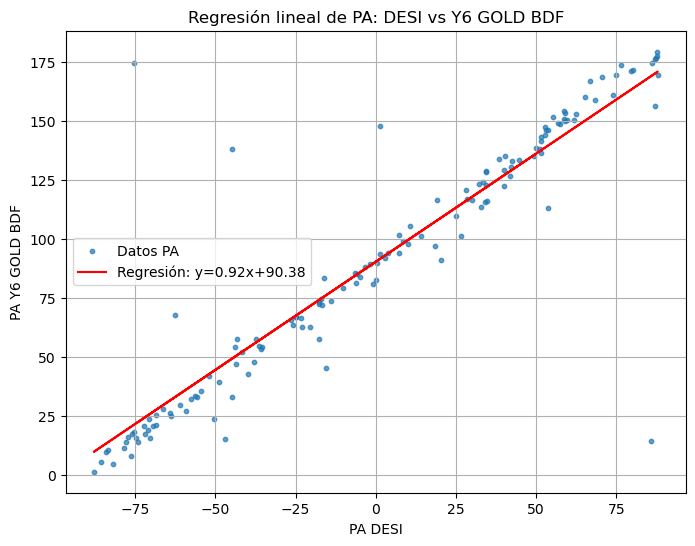

In [45]:
#Extraemos las columnas PA 
x = crossmatch_y6_desi['pos_angle']
y = crossmatch_y6_desi['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA DESI')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: DESI vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

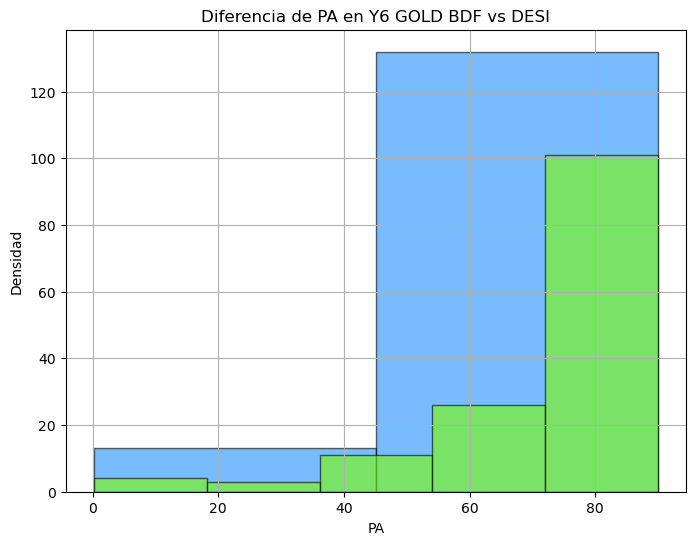

In [46]:
#Hacemos un histograma de la resta entre PA_BDF y PA_Y6
crossmatch_y6_desi['delta_PA'] = (crossmatch_y6_desi['BDF_phi'] - crossmatch_y6_desi['THETA_J2000']) % 180
crossmatch_y6_desi['delta_PA'] = np.where(crossmatch_y6_desi['delta_PA'] > 90, 180 - crossmatch_y6_desi['delta_PA'], crossmatch_y6_desi['delta_PA'])

plt.figure(figsize=(8, 6))
plt.hist(crossmatch_y6_desi['delta_PA'], bins=2, color='dodgerblue', alpha=0.6, edgecolor='black')
plt.hist(crossmatch_y6_desi['delta_PA'], bins=5, color='lawngreen', alpha=0.6, edgecolor='black')
plt.xlabel('PA')
plt.ylabel('Densidad')
plt.title('Diferencia de PA en Y6 GOLD BDF vs DESI')
plt.grid(True)
plt.show()

Regresión lineal: y = 0.9151*x + 0.2425
Coeficiente de correlación (r): 0.8621
Error estándar: 0.0450
p-valor: 4.5822e-44


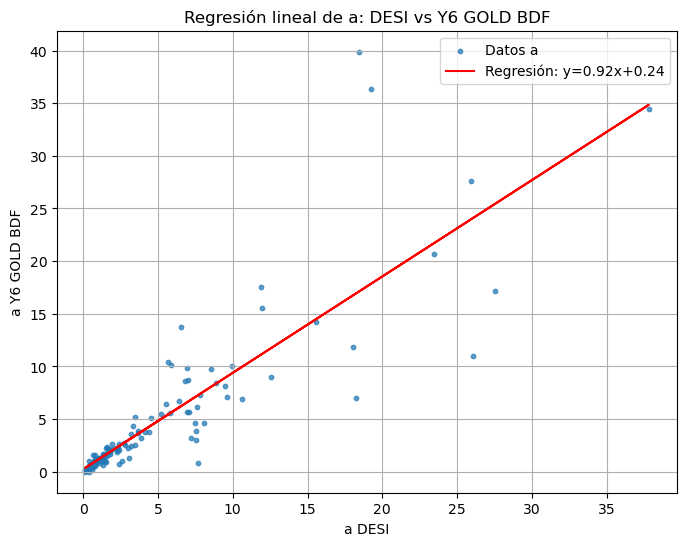

In [47]:
#Extraemos las columnas a 
x = crossmatch_y6_desi['a_axis']
y = crossmatch_y6_desi['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a DESI')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: DESI vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.9446*x + 0.1329
Coeficiente de correlación (r): 0.8762
Error estándar: 0.0435
p-valor: 3.6256e-47


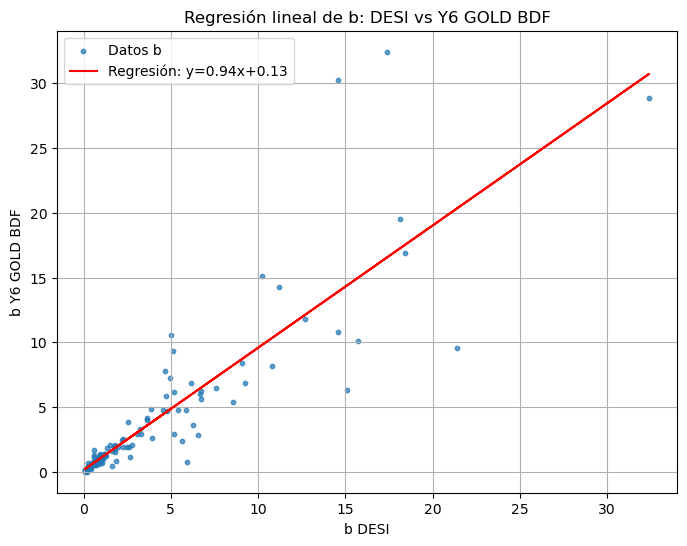

In [48]:
#Extraemos las columnas b 
x = crossmatch_y6_desi['b_axis']
y = crossmatch_y6_desi['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b DESI')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: DESI vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Vamos a estudiar alguna cosa más. Como Y6 GOLD y DES son iguales en cuanto a RA, DEC, PA, A y B, vamos a aprovechar que tenemos datos de magnitudes de Y6 GOLD para compararlas con las magnitudes de DESI.

In [49]:
print(df_filtered['BDF_MAG_G_CORRECTED'])
print(df_filtered['BDF_MAG_G'])
print(df_filtered['mag_g'])

0      13.522968
4      24.350453
8      18.267596
10     13.146501
11     19.815970
         ...    
708    23.454300
714    22.916036
723    20.700119
732    20.307749
734    25.220318
Name: BDF_MAG_G_CORRECTED, Length: 145, dtype: float64
0      13.714369
4      24.377381
8      18.317262
10     13.193174
11     19.853632
         ...    
708    23.734716
714    22.971292
723    20.736724
732    20.337441
734    25.277209
Name: BDF_MAG_G, Length: 145, dtype: float64
0      13.655043
4      23.938633
8      18.327845
10     12.825299
11     19.472927
         ...    
708    23.536451
714    22.836309
723    20.595592
732    20.150826
734    23.676819
Name: mag_g, Length: 145, dtype: float64


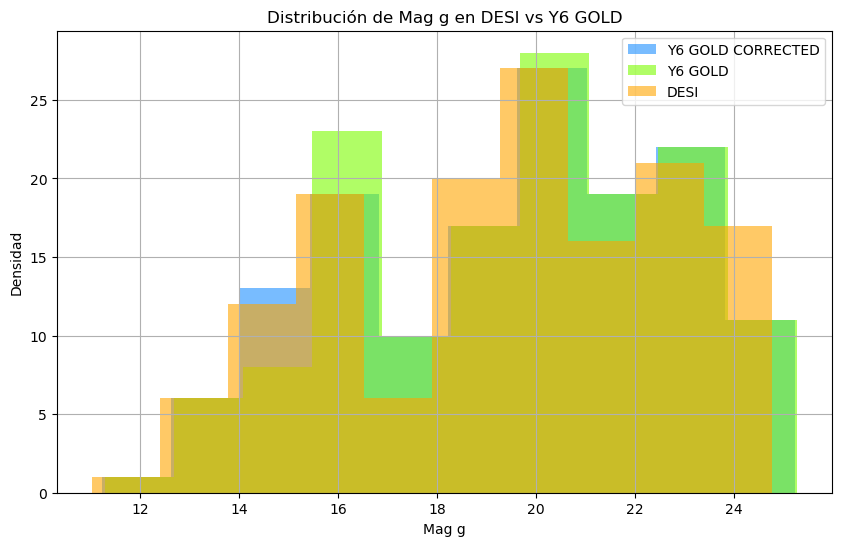

In [50]:
#Hacemos histogramas de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['BDF_MAG_G_CORRECTED'], bins=10, color='dodgerblue', alpha=0.6, label='Y6 GOLD CORRECTED')
plt.hist(df_filtered['BDF_MAG_G'], bins=10, color='lawngreen', alpha=0.6, label='Y6 GOLD')
plt.hist(df_filtered['mag_g'], bins=10, color='orange', alpha=0.6, label='DESI')
plt.xlabel('Mag g')
plt.ylabel('Densidad')
plt.title('Distribución de Mag g en DESI vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
#Hacemos la diferencia entre las magnitudes
diff_mag_g_bdf_bdf_corrected = df_filtered['BDF_MAG_G'] - df_filtered['BDF_MAG_G_CORRECTED']
diff_mag_g_desi_bdf_corrected = df_filtered['BDF_MAG_G_CORRECTED'] - df_filtered['mag_g']
diff_mag_g_desi_bdf = df_filtered['BDF_MAG_G'] - df_filtered['mag_g']

print(diff_mag_g_bdf_bdf_corrected)
print(diff_mag_g_desi_bdf_corrected)
print(diff_mag_g_desi_bdf)

0      0.191402
4      0.026928
8      0.049666
10     0.046673
11     0.037663
         ...   
708    0.280416
714    0.055256
723    0.036604
732    0.029692
734    0.056891
Length: 145, dtype: float64
0     -0.132075
4      0.411820
8     -0.060249
10     0.321202
11     0.343043
         ...   
708   -0.082152
714    0.079727
723    0.104527
732    0.156924
734    1.543499
Length: 145, dtype: float64
0      0.059327
4      0.438748
8     -0.010583
10     0.367875
11     0.380705
         ...   
708    0.198264
714    0.134982
723    0.141131
732    0.186616
734    1.600390
Length: 145, dtype: float64


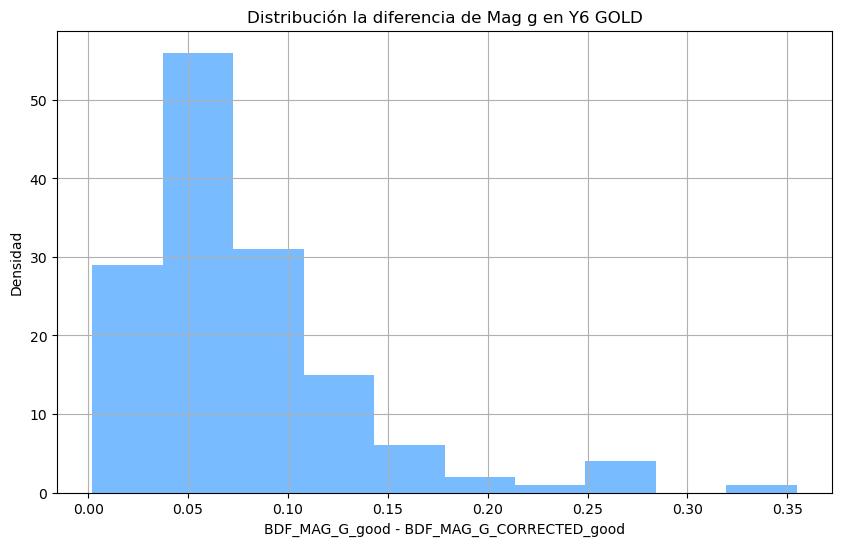

In [52]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_g_bdf_bdf_corrected, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_G_good - BDF_MAG_G_CORRECTED_good')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag g en Y6 GOLD')
plt.grid(True)
plt.show()

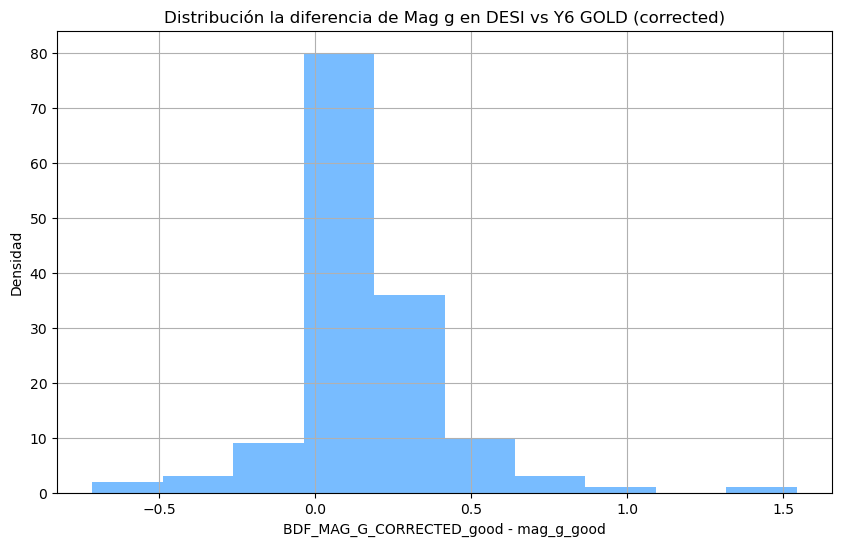

In [53]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_g_desi_bdf_corrected, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_G_CORRECTED_good - mag_g_good')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag g en DESI vs Y6 GOLD (corrected)')
plt.grid(True)
plt.show()

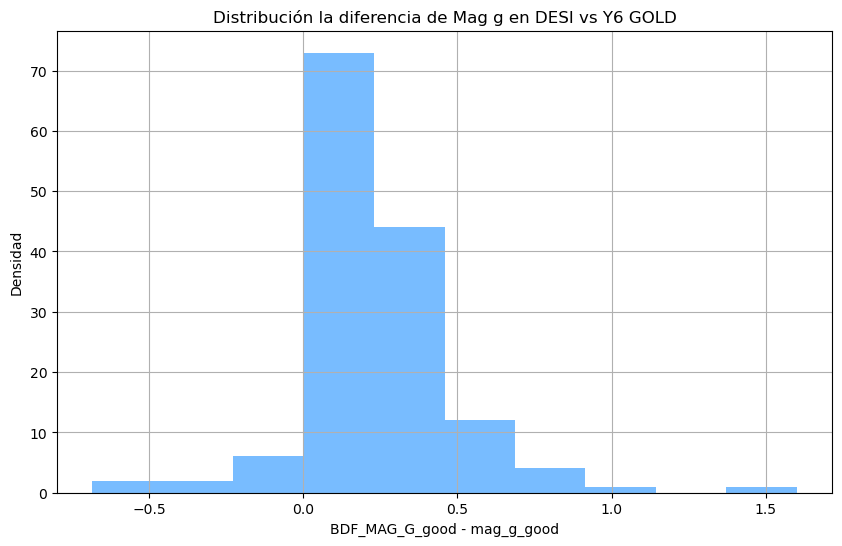

In [54]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_g_desi_bdf, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_G_good - mag_g_good')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag g en DESI vs Y6 GOLD')
plt.grid(True)
plt.show()

In [55]:
print(df_filtered['BDF_MAG_R_CORRECTED'])
print(df_filtered['BDF_MAG_R'])
print(df_filtered['mag_r'])

0      12.714310
4      23.861538
8      17.488000
10     12.319840
11     18.762381
         ...    
708    22.940393
714    21.541778
723    19.218052
732    18.784556
734    23.742326
Name: BDF_MAG_R_CORRECTED, Length: 145, dtype: float64
0      12.840376
4      23.873344
8      17.507944
10     12.346571
11     18.783046
         ...    
708    23.045784
714    21.578287
723    19.234762
732    18.805698
734    23.773615
Name: BDF_MAG_R, Length: 145, dtype: float64
0      12.887554
4      23.498995
8      17.319546
10     12.009613
11     18.390459
         ...    
708    22.806747
714    21.441700
723    19.105728
732    18.636002
734    22.565363
Name: mag_r, Length: 145, dtype: float64


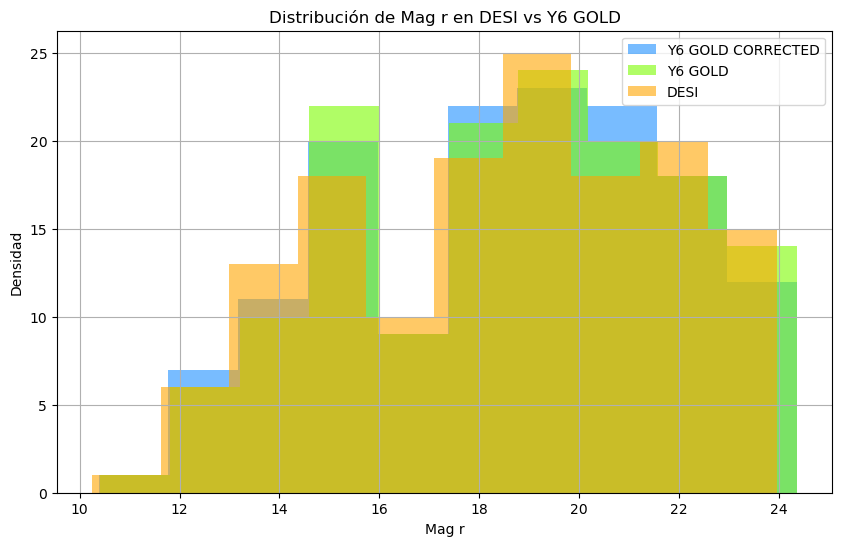

In [56]:
#Hacemos histogramas de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['BDF_MAG_R_CORRECTED'], bins=10, color='dodgerblue', alpha=0.6, label='Y6 GOLD CORRECTED')
plt.hist(df_filtered['BDF_MAG_R'], bins=10, color='lawngreen', alpha=0.6, label='Y6 GOLD')
plt.hist(df_filtered['mag_r'], bins=10, color='orange', alpha=0.6, label='DESI')
plt.xlabel('Mag r')
plt.ylabel('Densidad')
plt.title('Distribución de Mag r en DESI vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
#Hacemos la diferencia de las magnitudes
diff_mag_r_bdf_bdf_corrected = df_filtered['BDF_MAG_R'] - df_filtered['BDF_MAG_R_CORRECTED']
diff_mag_r_desi_bdf_corrected = df_filtered['BDF_MAG_R_CORRECTED'] - df_filtered['mag_r']
diff_mag_r_desi_bdf = df_filtered['BDF_MAG_R'] - df_filtered['mag_r']

print(diff_mag_r_bdf_bdf_corrected)
print(diff_mag_r_desi_bdf_corrected)
print(diff_mag_r_desi_bdf)

0      0.126065
4      0.011806
8      0.019944
10     0.026730
11     0.020665
         ...   
708    0.105392
714    0.036509
723    0.016710
732    0.021142
734    0.031289
Length: 145, dtype: float64
0     -0.173244
4      0.362543
8      0.168454
10     0.310227
11     0.371922
         ...   
708    0.133645
714    0.100078
723    0.112324
732    0.148554
734    1.176963
Length: 145, dtype: float64
0     -0.047178
4      0.374349
8      0.188398
10     0.336958
11     0.392587
         ...   
708    0.239037
714    0.136587
723    0.129034
732    0.169696
734    1.208252
Length: 145, dtype: float64


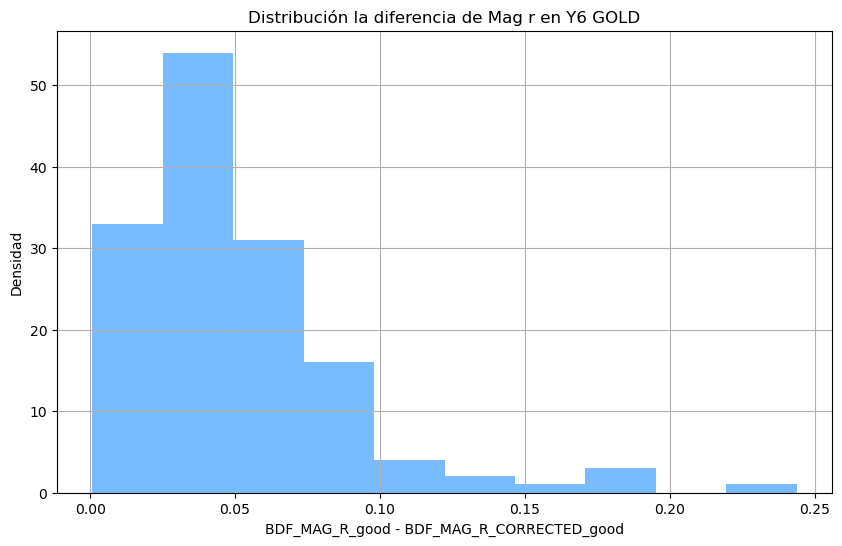

In [58]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_r_bdf_bdf_corrected, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_R_good - BDF_MAG_R_CORRECTED_good')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag r en Y6 GOLD')
plt.grid(True)
plt.show()

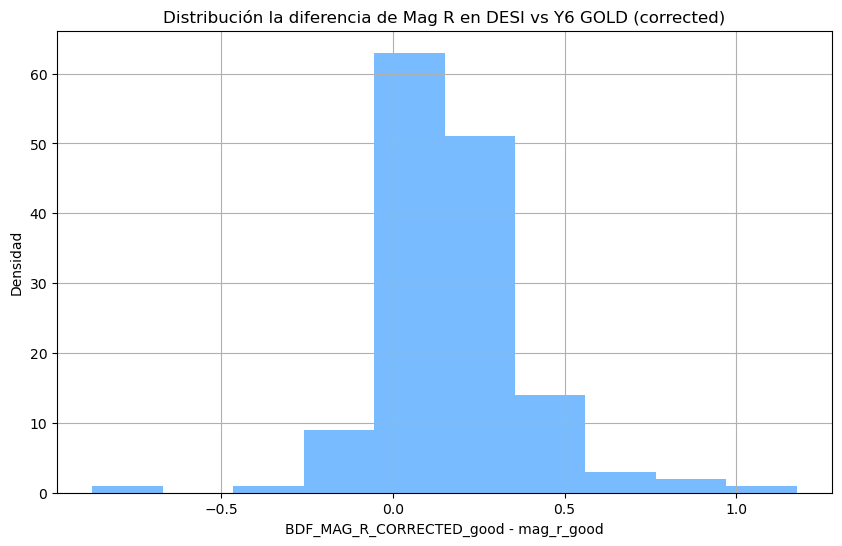

In [59]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_r_desi_bdf_corrected, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_R_CORRECTED_good - mag_r_good')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag R en DESI vs Y6 GOLD (corrected)')
plt.grid(True)
plt.show()

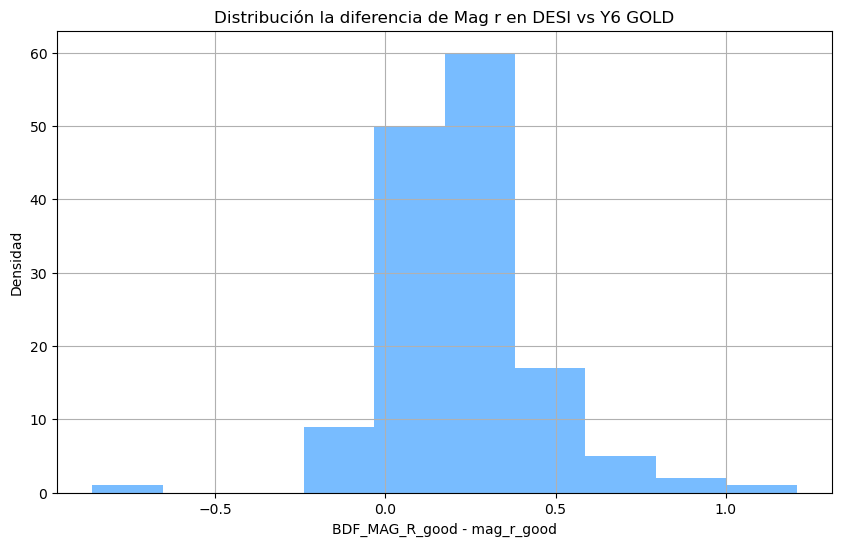

In [60]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_r_desi_bdf, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_R_good - mag_r_good')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag r en DESI vs Y6 GOLD')
plt.grid(True)
plt.show()

In [61]:
print(df_filtered['BDF_MAG_Z_CORRECTED'])
print(df_filtered['BDF_MAG_Z'])
print(df_filtered['mag_z'])

0      12.080465
4      23.231557
8      16.767943
10     11.686680
11     17.461996
         ...    
708    21.450788
714    20.532962
723    18.197054
732    17.903702
734    21.993897
Name: BDF_MAG_Z_CORRECTED, Length: 145, dtype: float64
0      12.148625
4      23.233070
8      16.778122
10     11.696129
11     17.464818
         ...    
708    21.510137
714    20.551902
723    18.209308
732    17.901349
734    22.006472
Name: BDF_MAG_Z, Length: 145, dtype: float64
0      12.318354
4      22.748520
8      16.533051
10     11.438227
11     17.134865
         ...    
708    21.417500
714    20.467577
723    18.121813
732    17.781864
734    21.040230
Name: mag_z, Length: 145, dtype: float64


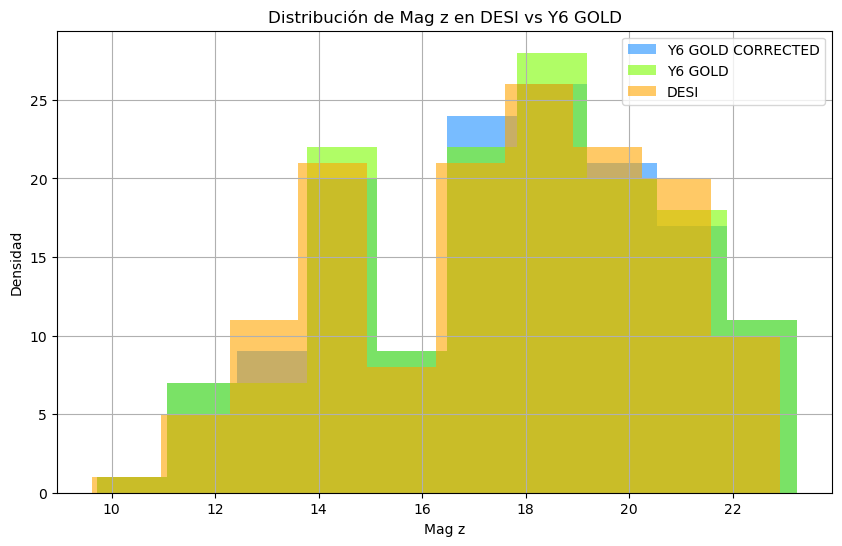

In [62]:
#Hacemos histogramas de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['BDF_MAG_Z_CORRECTED'], bins=10, color='dodgerblue', alpha=0.6, label='Y6 GOLD CORRECTED')
plt.hist(df_filtered['BDF_MAG_Z'], bins=10, color='lawngreen', alpha=0.6, label='Y6 GOLD')
plt.hist(df_filtered['mag_z'], bins=10, color='orange', alpha=0.6, label='DESI')
plt.xlabel('Mag z')
plt.ylabel('Densidad')
plt.title('Distribución de Mag z en DESI vs Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
#Hacemos la diferencia entre las magnitudes
diff_mag_z_bdf_bdf_corrected = df_filtered['BDF_MAG_Z'] - df_filtered['BDF_MAG_Z_CORRECTED']
diff_mag_z_desi_bdf_corrected = df_filtered['BDF_MAG_Z_CORRECTED'] - df_filtered['mag_z']
diff_mag_z_desi_bdf = df_filtered['BDF_MAG_Z'] - df_filtered['mag_z']

print(diff_mag_z_bdf_bdf_corrected)
print(diff_mag_z_desi_bdf_corrected)
print(diff_mag_z_desi_bdf)

0      0.068159
4      0.001513
8      0.010179
10     0.009449
11     0.002822
         ...   
708    0.059349
714    0.018941
723    0.012254
732   -0.002354
734    0.012575
Length: 145, dtype: float64
0     -0.237888
4      0.483037
8      0.234893
10     0.248453
11     0.327131
         ...   
708    0.033289
714    0.065385
723    0.075242
732    0.121838
734    0.953667
Length: 145, dtype: float64
0     -0.169729
4      0.484550
8      0.245071
10     0.257902
11     0.329953
         ...   
708    0.092637
714    0.084325
723    0.087495
732    0.119485
734    0.966242
Length: 145, dtype: float64


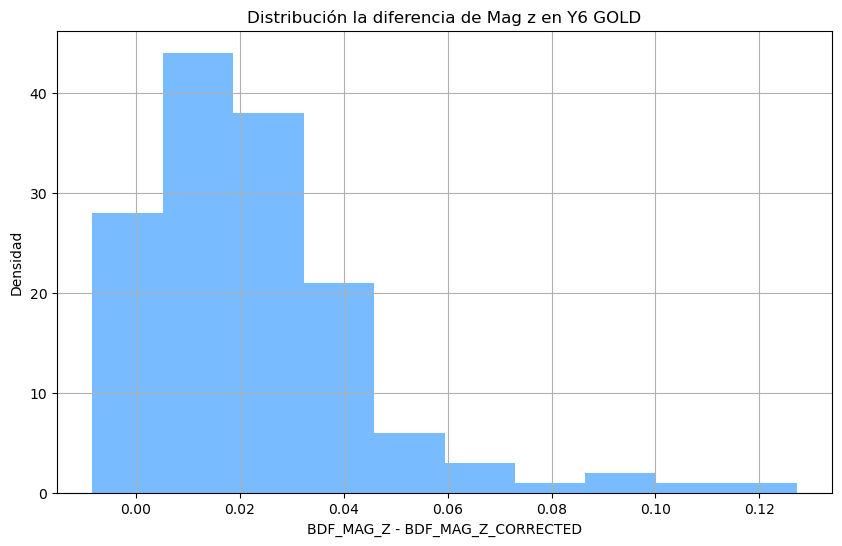

In [64]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_z_bdf_bdf_corrected, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_Z - BDF_MAG_Z_CORRECTED')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag z en Y6 GOLD')
plt.grid(True)
plt.show()

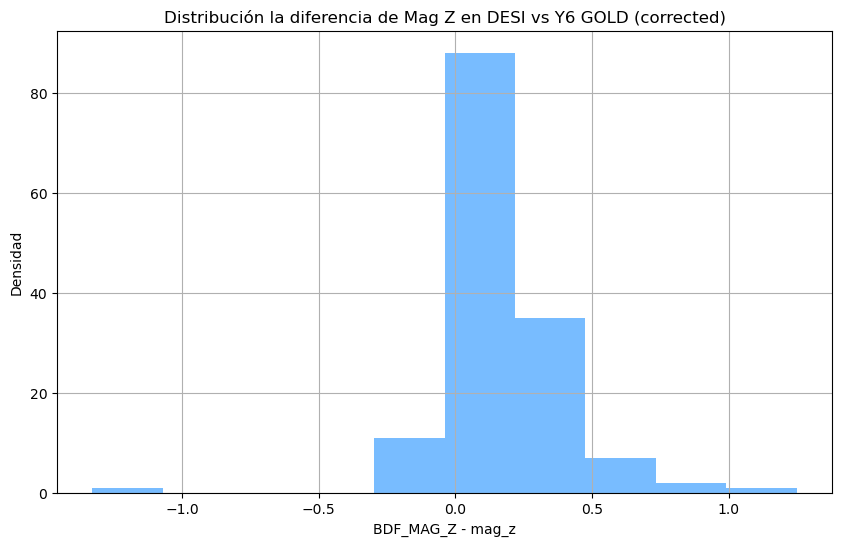

In [65]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_z_desi_bdf_corrected, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_Z - mag_z')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag Z en DESI vs Y6 GOLD (corrected)')
plt.grid(True)
plt.show()

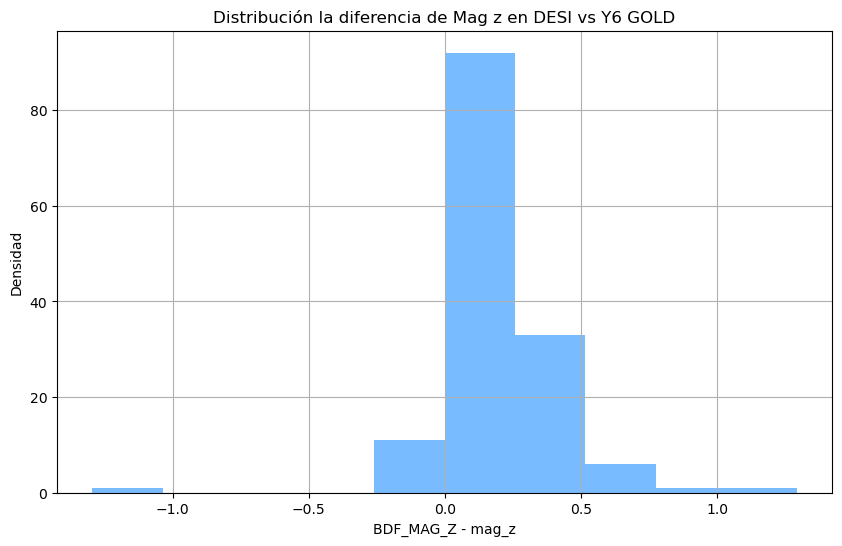

In [66]:
#Hacemos histogramas de la diferencia de las magnitudes
plt.figure(figsize=(10, 6))
plt.hist(diff_mag_z_desi_bdf, bins=10, color='dodgerblue', alpha=0.6)
plt.xlabel('BDF_MAG_Z - mag_z')
plt.ylabel('Densidad')
plt.title('Distribución la diferencia de Mag z en DESI vs Y6 GOLD')
plt.grid(True)
plt.show()